DAY 13: THE CAPSTONE INTEGRATION CHALLENGE

Feature               Meaning                                   Range 
--------------------  ----------------------------------------  ----- 
 tech_skill           Coding/technical level                    1–10  
 communication        Speaking & clarity                        1–10  
 interview_exposure   No. of interviews                         0–20 
 confidence           Self-belief (from assessment reflection)  1–10 
 problem_solving      Logical thinking                          1–10 


In [21]:
import pandas as pd

#Importing dataset

df=pd.read_csv("dataset.csv")
print("Dataset Preview: \n" , df.head())
print(df.info())
print(df.isnull().sum())

Dataset Preview: 
    tech_diff  comm_diff  exposure_diff  confidence_diff  problem_diff  \
0          2          8              1                7             9   
1         10          2              0                3             2   
2          5          6              4                3             7   
3          7          2              5                1             6   
4          5          2              8                1             4   

   compatibility  
0              1  
1              0  
2              0  
3              1  
4              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tech_diff        59 non-null     int64
 1   comm_diff        59 non-null     int64
 2   exposure_diff    59 non-null     int64
 3   confidence_diff  59 non-null     int64
 4   problem_diff     59 non-null     int64
 5   compatibility

In [22]:
#Data Preprocessing

X = df.drop("compatibility", axis=1)
y = df["compatibility"]

In [23]:
# Train-Test Split 

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
#Polynomial Features

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [26]:
#Train Model (Random Forest)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_poly, y_train)

RandomForestClassifier(random_state=42)

In [27]:
#Predictions

y_pred = model.predict(X_test_poly)

In [28]:
#Evaluation

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("\n===== EVALUATION =====")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


===== EVALUATION =====
Confusion Matrix:
 [[3 1]
 [2 6]]
Accuracy: 0.75

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.86      0.75      0.80         8

    accuracy                           0.75        12
   macro avg       0.73      0.75      0.73        12
weighted avg       0.77      0.75      0.76        12



In [29]:
#Feature Importance

feature_names = poly.get_feature_names_out()
importance = model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n", feature_df.head(10))


Top Features:
                           Feature  Importance
2                       comm_diff    0.166400
8         tech_diff exposure_diff    0.109795
12        comm_diff exposure_diff    0.091739
15                exposure_diff^2    0.086590
11                    comm_diff^2    0.078481
3                   exposure_diff    0.074676
13      comm_diff confidence_diff    0.072177
16  exposure_diff confidence_diff    0.064759
14         comm_diff problem_diff    0.051027
17     exposure_diff problem_diff    0.048429


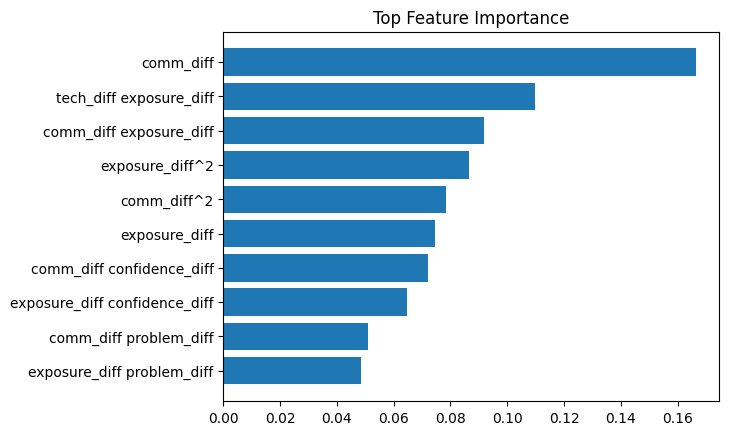

In [30]:
#Visualization

import matplotlib.pyplot as plt
top_features = feature_df.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top Feature Importance")
plt.gca().invert_yaxis()
plt.show()


In [33]:
#Prediction

import warnings
warnings.filterwarnings("ignore")
sample_df = pd.DataFrame([[0, 1, 20, 7, 1]])

sample_poly = poly.transform(sample_df)

prediction = model.predict(sample_poly)

print("\nPrediction:", "Compatible" if prediction[0] == 1 else "Not Compatible")


Prediction: Not Compatible
